# Import variables 

In [1]:
import copy
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandapower as pp


data_dir = Path("Data")
output_dir = Path("output")
data_dir.mkdir(exist_ok=True)
output_dir.mkdir(exist_ok=True)

with open(data_dir / "ffor_data.pkl", "rb") as f_pkl:
    d = pickle.load(f_pkl)
locals().update(d)

scenario_file = data_dir / "ffor_grid_scenarios.pkl"
if not scenario_file.exists():
    raise FileNotFoundError(
        f"Unable to find {scenario_file}. Run first grid_generation_belalp.ipynb."
    )
with open(scenario_file, "rb") as f_pkl:
    scenarios = pickle.load(f_pkl)

scenario_keys = ["without_belalp", "with_belalp"]
scenario_labels = {
    "without_belalp": "Without BelalpSolar",
    "with_belalp": "With BelalpSolar",
}
scenario_colors = {
    "without_belalp": "#1D4ED8",
    "with_belalp": "#15803D",
}

base_alpha = float(globals().get("alpha", 0.3))
base_cos_phi = float(globals().get("cos_phi", 0.95))

print("Data loaded from ffor_data.pkl")
for key in scenario_keys:
    scenario = scenarios[key]
    print(
        f"{scenario_labels[key]}: {scenario['n_nodes']} bus, "
        f"{len(scenario['line_data'])} lines, "
        f"P_base={float(scenario['P_base']):.3f} MW, "
        f"Q_base={float(scenario['Q_base']):.3f} MVAr"
    )


Data loaded from ffor_data.pkl
Without BelalpSolar: 76 bus, 75 lines, P_base=8.919 MW, Q_base=3.750 MVAr
With BelalpSolar: 77 bus, 76 lines, P_base=7.531 MW, Q_base=3.718 MVAr


# FFOR function

In [2]:
import gurobipy as gp
from gurobipy import GRB


SENSITIVITY_MODEL_VERSION = "2026-06-07-corrected-v2"
# 36 directions (10-degree steps) are sufficient to compare trends.
n_angles = 36
angles = np.linspace(0, 2 * np.pi, n_angles, endpoint=False)


def get_mapping_value(mapping, bus, default=0.0):
    """Reads a value from a dict or Series with int/str keys."""
    if mapping is None:
        return default
    for key in (bus, int(bus), str(bus)):
        try:
            if key in mapping:
                return mapping[key]
        except (TypeError, KeyError):
            pass
    return default


def polygon_area(P_points, Q_points):
    """Area using the shoelace formula for a closed, ordered contour."""
    P_boundary = np.asarray(P_points[:-1], dtype=float)
    Q_boundary = np.asarray(Q_points[:-1], dtype=float)
    if len(P_boundary) < 3:
        return 0.0
    return 0.5 * abs(
        np.dot(P_boundary, np.roll(Q_boundary, 1))
        - np.dot(Q_boundary, np.roll(P_boundary, 1))
    )


def ffor_spans(ffor):
    """Active and reactive spans, useful even when the area is zero."""
    return {
        "P_span_MW": float(max(ffor["P"]) - min(ffor["P"])),
        "Q_span_MVAr": float(max(ffor["Q"]) - min(ffor["Q"])),
    }


def assert_complete_ffor(ffor, label, n_expected):
    """Prevents missing AC points from being connected artificially."""
    if ffor["n_valid"] != n_expected or ffor["n_rejected"]:
        raise RuntimeError(
            f"Incomplete FFOR for {label}: "
            f"{ffor['n_valid']}/{n_expected} valid AC directions."
        )


def local_irradiance_factor(scenario, bus):
    """Retrieves the mean factor used to build the base scenario."""
    bus = int(bus)
    base_installed = float(
        get_mapping_value(globals().get("P_pv_installed"), bus, 0.0)
    )
    base_available = float(scenario["P_pv_available"].get(bus, 0.0))
    if base_installed > 1e-12:
        return float(np.clip(base_available / base_installed, 0.0, 1.0))

    scenario_cos_phi = float(scenario.get("cos_phi", base_cos_phi))
    inferred_installed = (
        float(scenario["S_inv_max"].get(bus, 0.0)) * scenario_cos_phi
    )
    if inferred_installed > 1e-12:
        return float(np.clip(base_available / inferred_installed, 0.0, 1.0))
    return 0.0


def build_pv_controls(scenario, alpha_value=None, cos_phi_value=None):
    """Builds PV limits consistent with the reference scenario."""
    alpha_value = base_alpha if alpha_value is None else float(alpha_value)
    cos_phi_value = base_cos_phi if cos_phi_value is None else float(cos_phi_value)
    if not 0.0 <= alpha_value <= 1.0:
        raise ValueError("alpha must be between 0 and 1.")
    if not 0.0 < cos_phi_value <= 1.0:
        raise ValueError("cos_phi must be strictly positive and <= 1.")

    tan_phi = np.tan(np.arccos(cos_phi_value))
    metadata = scenario.get("metadata", {})
    belalp_bus_raw = metadata.get("belalp_bus")
    belalp_bus = int(belalp_bus_raw) if belalp_bus_raw is not None else None

    P_pv_available = {}
    Q_pv_max = {}
    S_inv_max = {}

    for bus in scenario["nodes"]:
        bus_int = int(bus)
        is_belalp = belalp_bus is not None and bus_int == belalp_bus

        if is_belalp:
            # alpha applies only to small distributed PV systems.
            # BelalpSolar conserve toujours son dimensionnement nominal.
            base_available = float(
                scenario["P_pv_available"].get(bus_int, 0.0)
            )
            base_installed = float(
                metadata.get(
                    "belalp_p_mwp",
                    scenario["S_inv_max"].get(bus_int, 0.0) * base_cos_phi,
                )
            )
            installed_mw = base_installed
            p_available = base_available
        else:
            load_reference = abs(
                float(scenario["P_load"].get(bus_int, 0.0))
            )
            installed_mw = alpha_value * load_reference
            p_available = (
                installed_mw * local_irradiance_factor(scenario, bus_int)
            )

        P_pv_available[bus_int] = p_available
        Q_pv_max[bus_int] = installed_mw * tan_phi
        S_inv_max[bus_int] = (
            installed_mw / cos_phi_value if installed_mw > 0.0 else 0.0
        )

    return {
        "P_pv_available": P_pv_available,
        "Q_pv_max": Q_pv_max,
        "S_inv_max": S_inv_max,
        "alpha": alpha_value,
        "cos_phi": cos_phi_value,
    }


def solve_ffor_direction(scenario, controls, a, b):
    """Solves an extreme point of the linearized FFOR."""
    nodes_local = list(map(int, scenario["nodes"]))
    pcc_bus_local = int(scenario["pcc_bus"])
    bus_position = {
        bus: index for index, bus in enumerate(nodes_local)
    }

    model = gp.Model(f"FFOR_sensitivity_{scenario['name']}")
    model.Params.OutputFlag = 0
    model.Params.DualReductions = 0

    Pk = model.addVars(nodes_local, lb=-GRB.INFINITY, name="Pk")
    Qk = model.addVars(nodes_local, lb=-GRB.INFINITY, name="Qk")
    theta = model.addVars(nodes_local, lb=-GRB.INFINITY, name="theta")
    delta_U = model.addVars(nodes_local, lb=-GRB.INFINITY, name="U")
    P_pv = model.addVars(nodes_local, lb=0.0, name="Ppv")
    Q_pv = model.addVars(nodes_local, lb=-GRB.INFINITY, name="Qpv")
    # Heat-pump consumption is negative. Without an explicit lb, Gurobi imposes lb=0.
    P_hp = model.addVars(
        nodes_local,
        lb=-GRB.INFINITY,
        ub=0.0,
        name="Php",
    )

    for bus in nodes_local:
        position = bus_position[bus]

        if bus != pcc_bus_local:
            model.addConstr(
                Pk[bus]
                == P_pv[bus]
                + P_hp[bus]
                + float(scenario["P_load"].get(bus, 0.0))
            )
            model.addConstr(
                Qk[bus]
                == Q_pv[bus]
                + float(scenario["Q_load"].get(bus, 0.0))
            )

        model.addConstr(
            Pk[bus]
            == scenario["P_ref"][position]
            + gp.quicksum(
                scenario["J_Ptheta"][position, other_position]
                * theta[other_bus]
                + scenario["J_PU"][position, other_position]
                * delta_U[other_bus]
                for other_position, other_bus in enumerate(nodes_local)
            )
        )
        model.addConstr(
            Qk[bus]
            == scenario["Q_ref"][position]
            + gp.quicksum(
                scenario["J_Qtheta"][position, other_position]
                * theta[other_bus]
                + scenario["J_QU"][position, other_position]
                * delta_U[other_bus]
                for other_position, other_bus in enumerate(nodes_local)
            )
        )

        pv_pmax = float(
            controls["P_pv_available"].get(bus, 0.0)
        )
        pv_qmax = float(controls["Q_pv_max"].get(bus, 0.0))
        inverter_smax = float(
            controls["S_inv_max"].get(bus, 0.0)
        )
        model.addConstr(P_pv[bus] <= pv_pmax)
        model.addConstr(Q_pv[bus] <= pv_qmax)
        model.addConstr(Q_pv[bus] >= -pv_qmax)
        model.addConstr(
            P_hp[bus]
            >= float(scenario["P_hp_max"].get(bus, 0.0))
        )

        if inverter_smax > 1e-9:
            model.addQConstr(
                P_pv[bus] * P_pv[bus]
                + Q_pv[bus] * Q_pv[bus]
                <= inverter_smax * inverter_smax
            )
        else:
            model.addConstr(P_pv[bus] == 0.0)
            model.addConstr(Q_pv[bus] == 0.0)

        model.addConstr(
            scenario["V"] + delta_U[bus]
            >= scenario["delta_Umin"] * scenario["V"]
        )
        model.addConstr(
            scenario["V"] + delta_U[bus]
            <= scenario["delta_Umax"] * scenario["V"]
        )

    for _, row in scenario["line_data"].iterrows():
        from_bus = int(row["from_bus"])
        to_bus = int(row["to_bus"])
        angle_delta = theta[from_bus] - theta[to_bus]
        voltage_delta = delta_U[from_bus] - delta_U[to_bus]
        # Total flow = base operating-point flow + linearized variation.
        Pij = (
            float(row["P_base"])
            - float(row["b"]) * angle_delta
            + float(row["g"]) * voltage_delta
        )
        Qij = (
            float(row["Q_base"])
            - float(row["g"]) * angle_delta
            - float(row["b"]) * voltage_delta
        )
        model.addQConstr(
            Pij * Pij + Qij * Qij
            <= float(row["S_max"]) ** 2
        )

    model.addConstr(theta[pcc_bus_local] == 0.0)
    model.addConstr(delta_U[pcc_bus_local] == 0.0)
    model.setObjective(
        a * Pk[pcc_bus_local] + b * Qk[pcc_bus_local],
        GRB.MINIMIZE,
    )
    model.optimize()

    if model.status != GRB.OPTIMAL:
        model.dispose()
        return None

    result = {
        "P_linear": float(Pk[pcc_bus_local].X),
        "Q_linear": float(Qk[pcc_bus_local].X),
        "delta_p": {
            bus: (
                0.0
                if bus == pcc_bus_local
                else float(Pk[bus].X)
                - float(scenario["P_ref"][bus_position[bus]])
            )
            for bus in nodes_local
        },
        "delta_q": {
            bus: (
                0.0
                if bus == pcc_bus_local
                else float(Qk[bus].X)
                - float(scenario["Q_ref"][bus_position[bus]])
            )
            for bus in nodes_local
        },
    }
    model.dispose()
    return result


def validate_ac_solution(scenario, solution):
    """Replays the dispatch in Pandapower and checks AC limits."""
    net = copy.deepcopy(scenario["mv_net"])
    for bus in map(int, scenario["nodes"]):
        delta_p = float(solution["delta_p"][bus])
        delta_q = float(solution["delta_q"][bus])
        if abs(delta_p) > 1e-10 or abs(delta_q) > 1e-10:
            pp.create_sgen(
                net,
                bus=bus,
                p_mw=delta_p,
                q_mvar=delta_q,
                name="Sensitivity FFOR AC validation",
            )

    try:
        pp.runpp(
            net,
            calculate_voltage_angles=True,
            numba=False,
            init="auto",
        )
    except Exception:
        return {
            "valid": False,
            "reason": "AC power flow did not converge",
        }

    nodes_local = list(map(int, scenario["nodes"]))
    vm_pu = net.res_bus.reindex(nodes_local)["vm_pu"]
    loading = net.res_line.loc[
        net.line["in_service"], "loading_percent"
    ]
    voltage_ok = bool(
        (vm_pu >= scenario["delta_Umin"] - 1e-6).all()
        and (vm_pu <= scenario["delta_Umax"] + 1e-6).all()
    )
    loading_ok = bool((loading <= 100.0 + 1e-6).all())
    return {
        "valid": voltage_ok and loading_ok,
        "reason": (
            "ok"
            if voltage_ok and loading_ok
            else "AC limit exceeded"
        ),
        "P": float(net.res_ext_grid["p_mw"].sum()),
        "Q": float(net.res_ext_grid["q_mvar"].sum()),
        "v_min_pu": float(vm_pu.min()),
        "v_max_pu": float(vm_pu.max()),
        "line_loading_max_percent": float(loading.max()),
    }


def compute_operating_point(scenario, controls):
    """AC point: available PV, heat pumps at the base profile, and zero Q_pv."""
    nodes_local = list(map(int, scenario["nodes"]))
    pcc_bus_local = int(scenario["pcc_bus"])
    bus_position = {
        bus: index for index, bus in enumerate(nodes_local)
    }
    net = copy.deepcopy(scenario["mv_net"])

    for bus in nodes_local:
        if bus == pcc_bus_local:
            continue
        target_p = (
            float(scenario["P_load"].get(bus, 0.0))
            + float(controls["P_pv_available"].get(bus, 0.0))
            + float(scenario["P_hp_max"].get(bus, 0.0))
        )
        target_q = float(scenario["Q_load"].get(bus, 0.0))
        delta_p = (
            target_p
            - float(scenario["P_ref"][bus_position[bus]])
        )
        delta_q = (
            target_q
            - float(scenario["Q_ref"][bus_position[bus]])
        )
        if abs(delta_p) > 1e-10 or abs(delta_q) > 1e-10:
            pp.create_sgen(
                net,
                bus=bus,
                p_mw=delta_p,
                q_mvar=delta_q,
                name="Sensitivity operating point",
            )

    pp.runpp(
        net,
        calculate_voltage_angles=True,
        numba=False,
        init="auto",
    )
    return {
        "P": float(net.res_ext_grid["p_mw"].sum()),
        "Q": float(net.res_ext_grid["q_mvar"].sum()),
    }


def compute_ffor_for_scenario(
    scenario,
    controls,
    n_angles_local=n_angles,
):
    """Sweeps the directions, validates them in AC, and returns the closed contour."""
    local_angles = np.linspace(
        0,
        2 * np.pi,
        n_angles_local,
        endpoint=False,
    )
    P_points = []
    Q_points = []
    rejected = []

    for phi in local_angles:
        solution = solve_ffor_direction(
            scenario,
            controls,
            np.cos(phi),
            np.sin(phi),
        )
        if solution is None:
            rejected.append((float(phi), "infeasible optimization"))
            continue
        ac_result = validate_ac_solution(scenario, solution)
        if not ac_result["valid"]:
            rejected.append((float(phi), ac_result["reason"]))
            continue
        P_points.append(ac_result["P"])
        Q_points.append(ac_result["Q"])

    if len(P_points) < 3:
        raise RuntimeError(
            f"Not enough valid AC points for {scenario['name']}."
        )

    P_points.append(P_points[0])
    Q_points.append(Q_points[0])
    return {
        "P": P_points,
        "Q": Q_points,
        "area": polygon_area(P_points, Q_points),
        "n_valid": len(P_points) - 1,
        "n_requested": n_angles_local,
        "n_rejected": len(rejected),
        "rejected": rejected,
        "operating_point": compute_operating_point(
            scenario,
            controls,
        ),
    }


def compute_base_ffor(scenario):
    controls = build_pv_controls(
        scenario,
        alpha_value=base_alpha,
        cos_phi_value=base_cos_phi,
    )
    return compute_ffor_for_scenario(scenario, controls)


def assert_base_controls_match_scenario(scenario):
    """Prevents missing data from silently corrupting the nominal case."""
    controls = build_pv_controls(
        scenario,
        alpha_value=base_alpha,
        cos_phi_value=base_cos_phi,
    )
    for control_name in ("P_pv_available", "Q_pv_max", "S_inv_max"):
        expected = np.array([
            float(scenario[control_name].get(int(bus), 0.0))
            for bus in scenario["nodes"]
        ])
        actual = np.array([
            float(controls[control_name].get(int(bus), 0.0))
            for bus in scenario["nodes"]
        ])
        if not np.allclose(actual, expected, rtol=1e-8, atol=1e-10):
            max_error = float(np.max(np.abs(actual - expected)))
            raise AssertionError(
                f"Inconsistent nominal case for {control_name}: "
                f"maximum error={max_error:.3e}."
            )


# 1. alpha sensitivity

`alpha` varies between 0 and 1 and multiplies the locally installed PV power by the active load at each bus. Active-power availability retains the mean irradiance factor of the reference scenario. In the scenario with BelalpSolar, BelalpSolar remains fixed to isolate the effect of local PV systems.

`cos(phi) = 0.95`. Each optimized point is replayed in Pandapower and retained only if it satisfies AC voltage and line-loading limits.

In [3]:
# ============================================================
# SENSITIVITY ANALYSIS - Alpha parameter, with and without BelalpSolar
# ============================================================

assert SENSITIVITY_MODEL_VERSION == "2026-06-07-corrected-v2", (
    "Restart the kernel and then run all cells in order."
)
for scenario_key in scenario_keys:
    assert_base_controls_match_scenario(scenarios[scenario_key])
print("Nominal PV check: OK for both scenarios.")

alpha_list = np.linspace(0, 1, 11)
sensitivity_results = {}

for scenario_key in scenario_keys:
    scenario = scenarios[scenario_key]
    print()
    print(f"=== {scenario_labels[scenario_key]} ===")

    scenario_result = {"alpha": {}}

    for alpha_test in alpha_list:
        controls = build_pv_controls(
            scenario,
            alpha_value=alpha_test,
            cos_phi_value=base_cos_phi,
        )
        ffor = compute_ffor_for_scenario(scenario, controls)
        assert_complete_ffor(
            ffor,
            f"{scenario_labels[scenario_key]}, alpha={alpha_test:.2f}",
            n_angles,
        )
        scenario_result["alpha"][float(alpha_test)] = ffor
        print(
            f"alpha={alpha_test:.2f} | "
            f"P=[{min(ffor['P']):.3f}, {max(ffor['P']):.3f}] MW | "
            f"Q=[{min(ffor['Q']):.3f}, {max(ffor['Q']):.3f}] MVAr | "
            f"area={ffor['area']:.3f} | "
            f"AC={ffor['n_valid']}/{n_angles}"
        )
    base_key = min(
        scenario_result["alpha"],
        key=lambda value: abs(value - base_alpha),
    )
    scenario_result["base"] = scenario_result["alpha"][base_key]

    sensitivity_results[scenario_key] = scenario_result

base_without = sensitivity_results["without_belalp"]["base"]
if ffor_spans(base_without)["P_span_MW"] < 1.0:
    raise AssertionError(
        "Abnormally small active-power span without BelalpSolar. "
        "Check that P_hp has lb=-GRB.INFINITY and restart the kernel."
    )

print()
print("Alpha sensitivity completed for both scenarios.")
print(
    "Definition: alpha modifies only the small distributed PV systems; "
    "BelalpSolar remains fixed."
)


Nominal PV check: OK for both scenarios.

=== Without BelalpSolar ===
Set parameter Username
Set parameter LicenseID to value 2805803
Academic license - for non-commercial use only - expires 2027-04-10
alpha=0.00 | P=[8.919, 14.564] MW | Q=[3.750, 3.832] MVAr | aire=0.000 | AC=36/36
alpha=0.10 | P=[8.775, 14.727] MW | Q=[3.455, 4.118] MVAr | aire=3.413 | AC=36/36
alpha=0.20 | P=[8.630, 14.888] MW | Q=[3.160, 4.404] MVAr | aire=7.087 | AC=36/36
alpha=0.30 | P=[8.486, 15.047] MW | Q=[2.866, 4.690] MVAr | aire=11.017 | AC=36/36
alpha=0.40 | P=[8.342, 15.207] MW | Q=[2.571, 4.976] MVAr | aire=15.203 | AC=36/36
alpha=0.50 | P=[8.198, 15.359] MW | Q=[2.277, 5.263] MVAr | aire=19.641 | AC=36/36
alpha=0.60 | P=[8.054, 15.503] MW | Q=[1.983, 5.551] MVAr | aire=24.318 | AC=36/36
alpha=0.70 | P=[7.911, 15.647] MW | Q=[1.689, 5.838] MVAr | aire=29.220 | AC=36/36
alpha=0.80 | P=[7.767, 15.720] MW | Q=[1.399, 6.126] MVAr | aire=34.293 | AC=36/36
alpha=0.90 | P=[7.625, 15.721] MW | Q=[1.111, 6.415] M

**Plot**

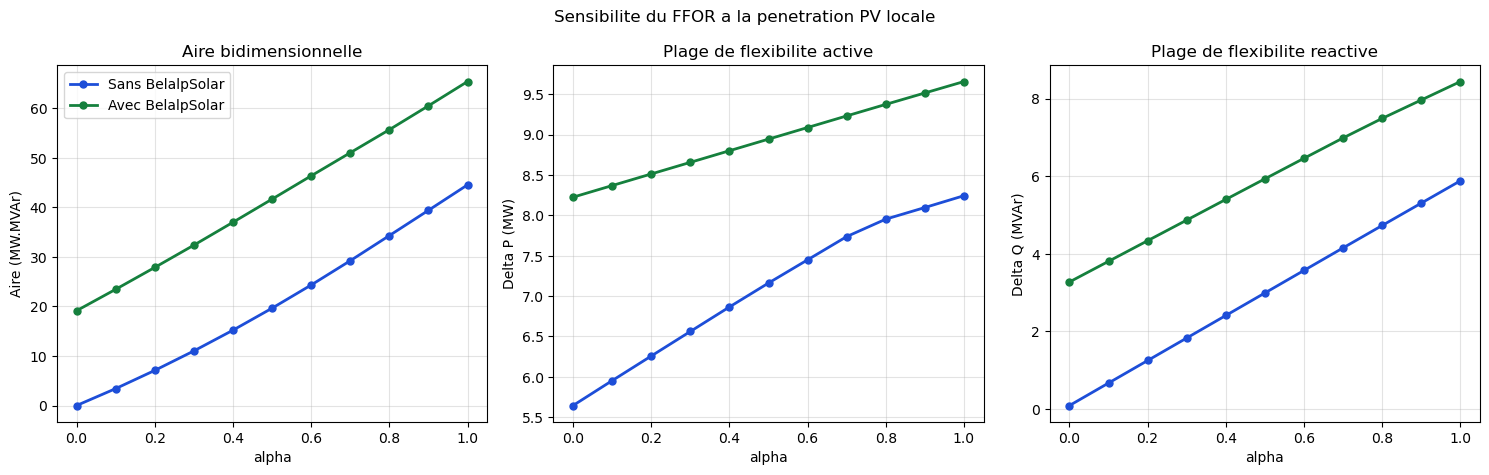

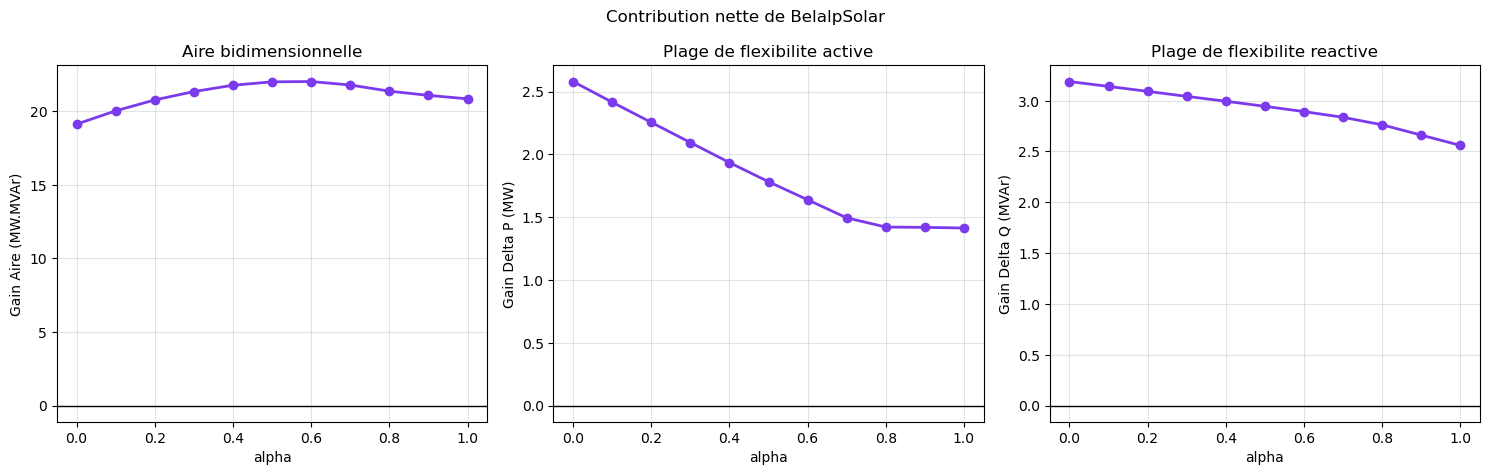

scenario,With BelalpSolar,Without BelalpSolar
alpha,,
0.0,19.131714,0.000038
0.1,23.449747,3.413464
0.2,27.865603,7.086646
0.3,32.364303,11.016716
0.4,36.980147,15.202757
0.5,41.649336,19.641385
0.6,46.347446,24.317951
0.7,51.013336,29.219691
0.8,55.667359,34.292803


In [4]:
# FFOR area and spans vs alpha, compared without/with BelalpSolar

alpha_area_rows = []
for scenario_key in scenario_keys:
    for alpha_test, ffor in sensitivity_results[scenario_key]["alpha"].items():
        alpha_area_rows.append({
            "scenario": scenario_labels[scenario_key],
            "scenario_key": scenario_key,
            "alpha": alpha_test,
            "area_MW_MVAr": ffor["area"],
            "P_min_MW": min(ffor["P"]),
            "P_max_MW": max(ffor["P"]),
            "Q_min_MVAr": min(ffor["Q"]),
            "Q_max_MVAr": max(ffor["Q"]),
            **ffor_spans(ffor),
            "n_valid": ffor["n_valid"],
            "n_rejected": ffor["n_rejected"],
        })

alpha_area_df = pd.DataFrame(alpha_area_rows)
alpha_area_df.to_csv(
    output_dir / "sensitivity_alpha_without_vs_with_belalp.csv",
    index=False,
)

metric_specs = [
    ("area_MW_MVAr", "Area (MW.MVAr)", "Two-dimensional area"),
    ("P_span_MW", "Delta P (MW)", "Active-power flexibility range"),
    ("Q_span_MVAr", "Delta Q (MVAr)", "Reactive-power flexibility range"),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, (column, ylabel, title) in zip(axes, metric_specs):
    for scenario_key in scenario_keys:
        df_s = alpha_area_df[
            alpha_area_df["scenario_key"] == scenario_key
        ].sort_values("alpha")
        ax.plot(
            df_s["alpha"],
            df_s[column],
            "o-",
            linewidth=2,
            markersize=5,
            color=scenario_colors[scenario_key],
            label=scenario_labels[scenario_key],
        )
    ax.set_xlabel("alpha")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.35)
axes[0].legend()
fig.suptitle("FFOR sensitivity to local PV penetration")
plt.tight_layout()
plt.savefig(
    output_dir / "sensitivity_alpha_area_without_vs_with_belalp.png",
    dpi=150,
)
plt.show()

# Paired gain provided by BelalpSolar. No ratio is calculated
# because the area without PV can be exactly zero at alpha=0.
paired_alpha = alpha_area_df.pivot(
    index="alpha",
    columns="scenario_key",
    values=[spec[0] for spec in metric_specs],
)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, (column, ylabel, title) in zip(axes, metric_specs):
    gain = (
        paired_alpha[(column, "with_belalp")]
        - paired_alpha[(column, "without_belalp")]
    )
    ax.plot(gain.index, gain.values, "o-", color="#7C3AED", linewidth=2)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_xlabel("alpha")
    ax.set_ylabel(f"Gain {ylabel}")
    ax.set_title(title)
    ax.grid(True, alpha=0.35)
fig.suptitle("Net contribution of BelalpSolar")
plt.tight_layout()
plt.savefig(
    output_dir / "sensitivity_alpha_area_rel_without_vs_with_belalp.png",
    dpi=150,
)
plt.savefig(
    output_dir / "sensitivity_alpha_belalp_gain.png",
    dpi=150,
)
plt.show()

display(
    alpha_area_df.pivot(
        index="alpha",
        columns="scenario",
        values="area_MW_MVAr",
    )
)


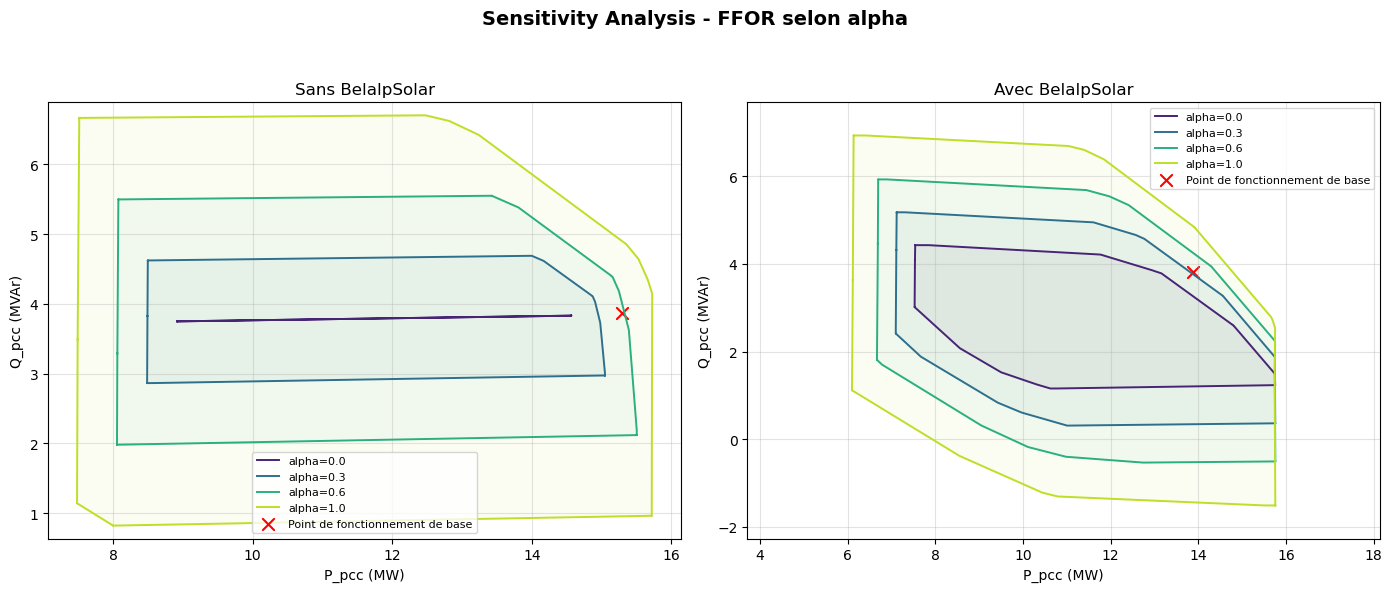

In [5]:
import matplotlib.cm as cm

# A few representative contours; overlaying all 11 would be unreadable.
alpha_values_to_plot = [0.0, base_alpha, 0.6, 1.0]
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
colors = cm.viridis(np.linspace(0.1, 0.9, len(alpha_values_to_plot)))

for ax, scenario_key in zip(axes, scenario_keys):
    base_ffor = sensitivity_results[scenario_key]["base"]

    for alpha_test, color in zip(alpha_values_to_plot, colors):
        alpha_key = min(
            sensitivity_results[scenario_key]["alpha"],
            key=lambda value: abs(value - alpha_test),
        )
        ffor = sensitivity_results[scenario_key]["alpha"][alpha_key]
        ax.plot(
            ffor["P"],
            ffor["Q"],
            color=color,
            linewidth=1.4,
            label=f"alpha={alpha_key:.1f}",
        )
        ax.fill(
            ffor["P"],
            ffor["Q"],
            alpha=0.05,
            color=color,
        )

    point = base_ffor["operating_point"]
    ax.scatter(
        [point["P"]],
        [point["Q"]],
        color="red",
        marker="x",
        s=65,
        label="Base operating point",
    )
    ax.set_title(scenario_labels[scenario_key])
    ax.set_xlabel("P_pcc (MW)")
    ax.set_ylabel("Q_pcc (MVAr)")
    ax.grid(True, alpha=0.35)
    ax.axis("equal")
    ax.legend(fontsize=8, loc="best")
fig.suptitle(
    "Sensitivity Analysis - FFOR by alpha",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(
    output_dir / "sensitivity_alpha_without_vs_with_belalp.png",
    dpi=150,
)
plt.show()


# 2. cos(phi) sensitivity

`alpha = 0.3` for local PV systems.

`cos(phi)` varies between 0.90 and 1.00. A lower value represents an inverter sized for greater apparent-power and reactive-power capability. At `cos(phi)=1`, no reactive-power exchange is allowed.

In [6]:
# ============================================================
# SENSITIVITY ANALYSIS - cos_phi parameter, with and without BelalpSolar
# ============================================================

# Range consistent with the stated analysis: 0.90 to 1.00.
cos_phi_list = [0.90, 0.925, 0.95, 0.975, 1.00]

for scenario_key in scenario_keys:
    scenario = scenarios[scenario_key]
    print()
    print(f"=== {scenario_labels[scenario_key]} ===")
    sensitivity_results.setdefault(scenario_key, {})
    sensitivity_results[scenario_key]["cos_phi"] = {}

    for cos_phi_test in cos_phi_list:
        controls = build_pv_controls(
            scenario,
            alpha_value=base_alpha,
            cos_phi_value=cos_phi_test,
        )
        ffor = compute_ffor_for_scenario(scenario, controls)
        assert_complete_ffor(
            ffor,
            f"{scenario_labels[scenario_key]}, cos_phi={cos_phi_test:.3f}",
            n_angles,
        )
        sensitivity_results[scenario_key]["cos_phi"][
            float(cos_phi_test)
        ] = ffor
        print(
            f"cos_phi={cos_phi_test:.3f} | "
            f"P=[{min(ffor['P']):.3f}, {max(ffor['P']):.3f}] MW | "
            f"Q=[{min(ffor['Q']):.3f}, {max(ffor['Q']):.3f}] MVAr | "
            f"area={ffor['area']:.3f} | "
            f"AC={ffor['n_valid']}/{n_angles}"
        )

print()
print("cos_phi sensitivity completed for both scenarios.")



=== Without BelalpSolar ===
cos_phi=0.900 | P=[8.484, 15.274] MW | Q=[2.450, 5.097] MVAr | aire=16.520 | AC=36/36
cos_phi=0.925 | P=[8.485, 15.167] MW | Q=[2.647, 4.904] MVAr | aire=13.896 | AC=36/36
cos_phi=0.950 | P=[8.486, 15.047] MW | Q=[2.866, 4.690] MVAr | aire=11.017 | AC=36/36
cos_phi=0.975 | P=[8.487, 14.900] MW | Q=[3.135, 4.427] MVAr | aire=7.551 | AC=36/36
cos_phi=1.000 | P=[8.490, 14.564] MW | Q=[3.744, 3.832] MVAr | aire=0.001 | AC=36/36

=== With BelalpSolar ===
cos_phi=0.900 | P=[7.096, 15.761] MW | Q=[-0.256, 5.497] MVAr | aire=38.284 | AC=36/36
cos_phi=0.925 | P=[7.096, 15.761] MW | Q=[-0.105, 5.346] MVAr | aire=35.901 | AC=36/36
cos_phi=0.950 | P=[7.097, 15.753] MW | Q=[0.312, 5.178] MVAr | aire=32.368 | AC=36/36
cos_phi=0.975 | P=[7.098, 15.568] MW | Q=[1.302, 4.970] MVAr | aire=23.999 | AC=36/36
cos_phi=1.000 | P=[7.103, 13.161] MW | Q=[3.714, 3.782] MVAr | aire=0.002 | AC=36/36

cos_phi sensitivity completed for both scenarios.


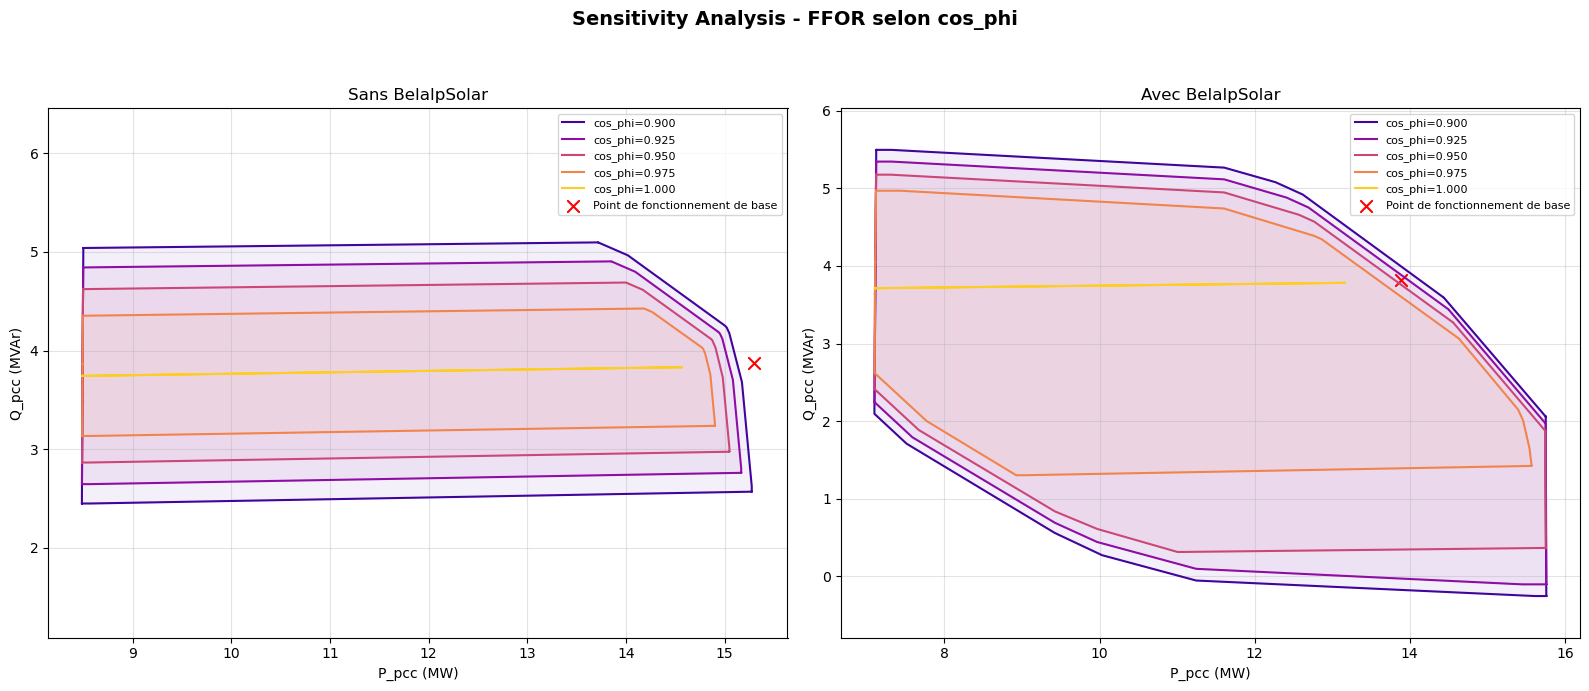

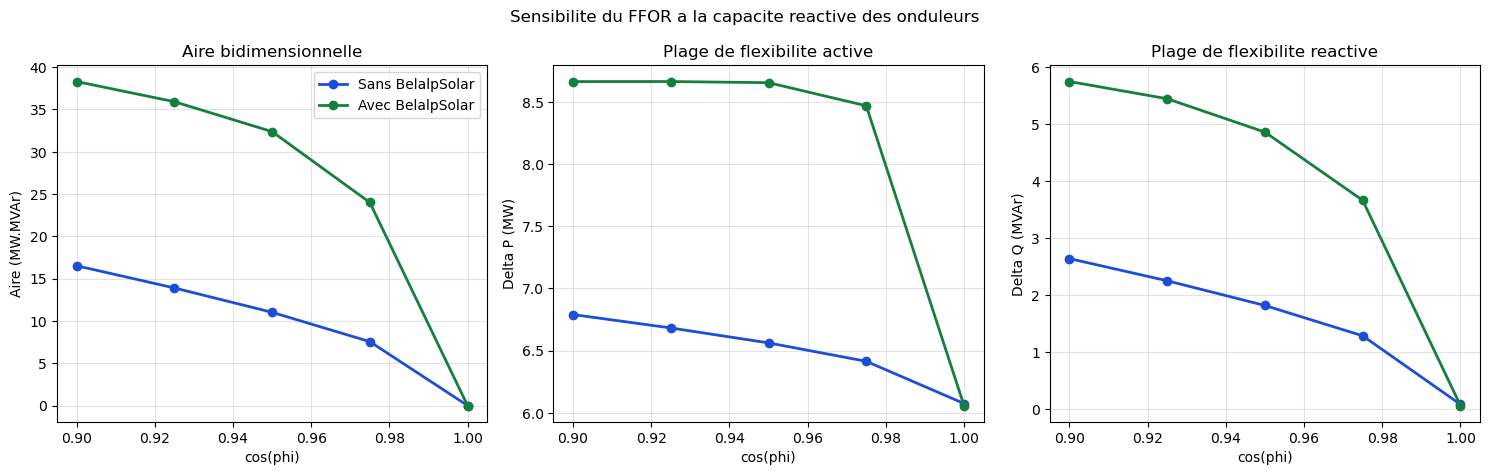

scenario,With BelalpSolar,Without BelalpSolar
cos_phi,,
0.900,38.284192,16.519570
0.925,35.901495,13.895727
0.950,32.368002,11.016522
0.975,23.999181,7.551377
1.000,0.002207,0.001090


In [7]:
import matplotlib.cm as cm

# FFOR contours for each cos_phi, separated by scenario
colors = cm.plasma(np.linspace(0.1, 0.9, len(cos_phi_list)))
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False)

for ax, scenario_key in zip(axes, scenario_keys):
    base_ffor = sensitivity_results[scenario_key]["cos_phi"][base_cos_phi]
    for (cos_phi_test, ffor), color in zip(
        sensitivity_results[scenario_key]["cos_phi"].items(),
        colors,
    ):
        ax.plot(
            ffor["P"],
            ffor["Q"],
            color=color,
            linewidth=1.5,
            label=f"cos_phi={cos_phi_test:.3f}",
        )
        ax.fill(
            ffor["P"],
            ffor["Q"],
            alpha=0.06,
            color=color,
        )

    point = base_ffor["operating_point"]
    ax.scatter(
        [point["P"]],
        [point["Q"]],
        color="red",
        marker="x",
        s=65,
        label="Base operating point",
    )
    ax.set_title(scenario_labels[scenario_key])
    ax.set_xlabel("P_pcc (MW)")
    ax.set_ylabel("Q_pcc (MVAr)")
    ax.grid(True, alpha=0.35)
    ax.axis("equal")
    ax.legend(fontsize=8, loc="best")
fig.suptitle(
    "Sensitivity Analysis - FFOR by cos_phi",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(
    output_dir / "sensitivity_cosphi_without_vs_with_belalp.png",
    dpi=150,
)
plt.show()

cosphi_area_rows = []
for scenario_key in scenario_keys:
    for cos_phi_test, ffor in sensitivity_results[
        scenario_key
    ]["cos_phi"].items():
        cosphi_area_rows.append({
            "scenario": scenario_labels[scenario_key],
            "scenario_key": scenario_key,
            "cos_phi": cos_phi_test,
            "area_MW_MVAr": ffor["area"],
            "P_min_MW": min(ffor["P"]),
            "P_max_MW": max(ffor["P"]),
            "Q_min_MVAr": min(ffor["Q"]),
            "Q_max_MVAr": max(ffor["Q"]),
            **ffor_spans(ffor),
            "n_valid": ffor["n_valid"],
            "n_rejected": ffor["n_rejected"],
        })
cosphi_area_df = pd.DataFrame(cosphi_area_rows)
cosphi_area_df.to_csv(
    output_dir / "sensitivity_cosphi_without_vs_with_belalp.csv",
    index=False,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, (column, ylabel, title) in zip(axes, metric_specs):
    for scenario_key in scenario_keys:
        df_s = cosphi_area_df[
            cosphi_area_df["scenario_key"] == scenario_key
        ].sort_values("cos_phi")
        ax.plot(
            df_s["cos_phi"],
            df_s[column],
            "o-",
            linewidth=2,
            color=scenario_colors[scenario_key],
            label=scenario_labels[scenario_key],
        )
    ax.set_xlabel("cos(phi)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.35)
axes[0].legend()
fig.suptitle("FFOR sensitivity to inverter reactive-power capability")
plt.tight_layout()
plt.savefig(
    output_dir / "sensitivity_cosphi_metrics_without_vs_with_belalp.png",
    dpi=150,
)
plt.show()

display(
    cosphi_area_df.pivot(
        index="cos_phi",
        columns="scenario",
        values="area_MW_MVAr",
    )
)


# Monte Carlo Analysis

Draws `alpha` and `cos_phi` simultaneously, then computes the FFOR area for both scenarios. The scenarios without and with BelalpSolar use exactly the same draws, enabling a paired comparison. The exploratory Monte Carlo uses 18 directions per contour; increase `n_monte_carlo` and `n_angles_monte_carlo` for a more accurate final analysis.


10/30 tirages communs termines
20/30 tirages communs termines
30/30 tirages communs termines


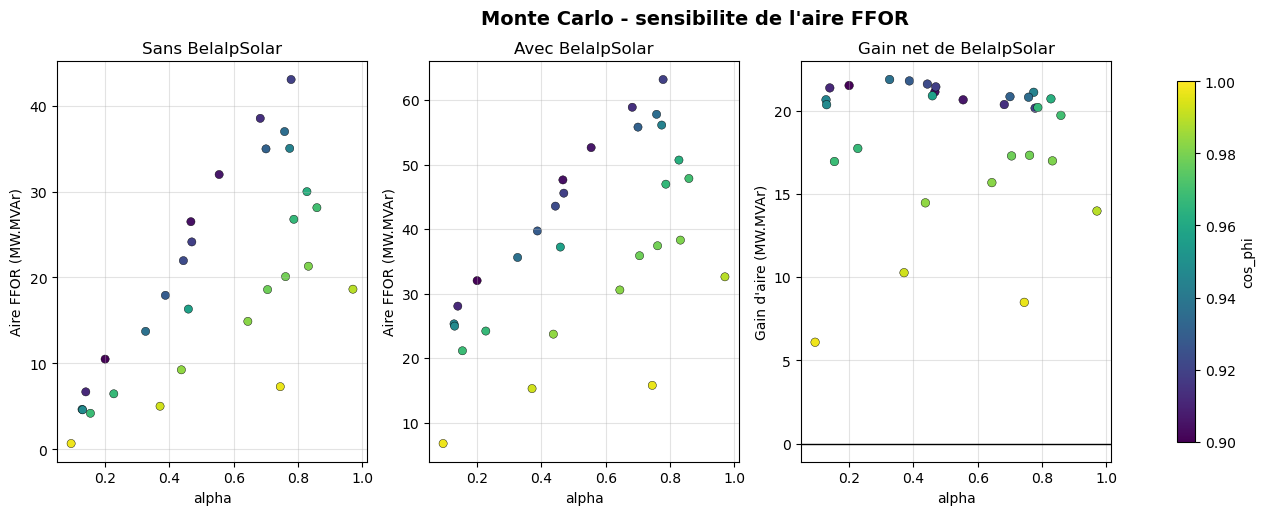

,quantity,mean_area_MW_MVAr,spearman_alpha,spearman_cos_phi
0,Without BelalpSolar,19.292310,0.746385,-0.434928
1,With BelalpSolar,37.708297,0.618687,-0.576863
2,Gain net BelalpSolar,18.415987,-0.174638,-0.843382


area_MW_MVAr                                             \
                        count       mean        std       min        25%   
scenario                                                                   
With BelalpSolar         30.0  37.708297  14.465652  6.761886  25.998942   
Without BelalpSolar         30.0  19.292310  11.964983  0.675460   7.783420   

                                                  P_min_MW            \
                        50%        75%        max    count      mean   
scenario                                                               
With BelalpSolar  37.320579  47.791317  63.189683     30.0  6.773224   
Without BelalpSolar  18.612132  27.784422  43.034299     30.0  8.160180   

                                                                              \
                       std       min       25%       50%       75%       max   
scenario                                                                       
With BelalpSolar  0.378493  6.142314  6.440463  6.792848  7.044271  7.392891   
Without BelalpSolar  0.380764  7.526569  7.825591  8.178965  8.432887  8.784202   

                 P_max_MW                                             \
                    count       mean       std        min        25%   
scenario                                                               
With BelalpSolar     30.0  15.569744  0.449734  13.939427  15.730339   
Without BelalpSolar     30.0  15.271512  0.364463  14.597044  14.896562   

                                                  Q_min_MVAr            \
                        50%        75%        max      count      mean   
scenario                                                                 
With BelalpSolar  15.750832  15.756699  15.765031       30.0  0.252802   
Without BelalpSolar  15.306857  15.599315  15.720112       30.0  2.350294   

                                                                              \
                       std       min       25%       50%       75%       max   
scenario                                                                       
With BelalpSolar  1.185411 -1.537588 -0.612640  0.106904  1.011493  3.085357   
Without BelalpSolar  0.808902  0.787683  1.788237  2.382791  3.143892  3.689585   

                 Q_max_MVAr                                                    \
                      count      mean       std       min       25%       50%   
scenario                                                                        
With BelalpSolar       30.0  5.620821  0.682106  4.352840  4.957572  5.640690   
Without BelalpSolar       30.0  5.192677  0.790266  3.889229  4.419548  5.158858   

                                      
                       75%       max  
scenario                              
With BelalpSolar  6.105933  6.903088  
Without BelalpSolar  5.742860  6.707755

In [8]:
# ============================================================
# MONTE CARLO - alpha and cos_phi, with and without BelalpSolar
# ============================================================

n_monte_carlo = 30
n_angles_monte_carlo = 18
rng = np.random.default_rng(42)

# Both scenarios use exactly the same draws.
monte_carlo_samples = [
    (
        float(rng.uniform(0.0, 1.0)),
        float(rng.uniform(0.90, 1.00)),
    )
    for _ in range(n_monte_carlo)
]
monte_carlo_rows = []

for sample_id, (alpha_sample, cos_phi_sample) in enumerate(
    monte_carlo_samples
):
    for scenario_key in scenario_keys:
        scenario = scenarios[scenario_key]
        controls = build_pv_controls(
            scenario,
            alpha_value=alpha_sample,
            cos_phi_value=cos_phi_sample,
        )
        ffor = compute_ffor_for_scenario(
            scenario,
            controls,
            n_angles_local=n_angles_monte_carlo,
        )
        assert_complete_ffor(
            ffor,
            f"Monte Carlo {sample_id}, {scenario_labels[scenario_key]}",
            n_angles_monte_carlo,
        )

        monte_carlo_rows.append({
            "scenario": scenario_labels[scenario_key],
            "scenario_key": scenario_key,
            "sample_id": sample_id,
            "alpha": alpha_sample,
            "cos_phi": cos_phi_sample,
            "area_MW_MVAr": ffor["area"],
            "P_min_MW": min(ffor["P"]),
            "P_max_MW": max(ffor["P"]),
            "Q_min_MVAr": min(ffor["Q"]),
            "Q_max_MVAr": max(ffor["Q"]),
            **ffor_spans(ffor),
            "n_valid": ffor["n_valid"],
            "n_rejected": ffor["n_rejected"],
        })

    if (sample_id + 1) % 10 == 0 or sample_id == n_monte_carlo - 1:
        print(f"{sample_id + 1}/{n_monte_carlo} shared draws completed")

monte_carlo_df = pd.DataFrame(monte_carlo_rows)
monte_carlo_df.to_csv(
    output_dir / "sensitivity_monte_carlo_without_vs_with_belalp.csv",
    index=False,
)

paired_mc = monte_carlo_df.pivot(
    index=["sample_id", "alpha", "cos_phi"],
    columns="scenario_key",
    values="area_MW_MVAr",
).reset_index()
paired_mc["belalp_area_gain"] = (
    paired_mc["with_belalp"] - paired_mc["without_belalp"]
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2), sharey=False)
for ax, scenario_key in zip(axes, scenario_keys):
    df_s = monte_carlo_df[
        monte_carlo_df["scenario_key"] == scenario_key
    ]
    sc = ax.scatter(
        df_s["alpha"],
        df_s["area_MW_MVAr"],
        c=df_s["cos_phi"],
        cmap="viridis",
        vmin=0.90,
        vmax=1.00,
        s=35,
        edgecolor="black",
        linewidth=0.3,
    )
    ax.set_title(scenario_labels[scenario_key])
    ax.set_xlabel("alpha")
    ax.set_ylabel("FFOR area (MW.MVAr)")
    ax.grid(True, alpha=0.35)

sc = axes[2].scatter(
    paired_mc["alpha"],
    paired_mc["belalp_area_gain"],
    c=paired_mc["cos_phi"],
    cmap="viridis",
    vmin=0.90,
    vmax=1.00,
    s=38,
    edgecolor="black",
    linewidth=0.3,
)
axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_title("Net gain from BelalpSolar")
axes[2].set_xlabel("alpha")
axes[2].set_ylabel("Area gain (MW.MVAr)")
axes[2].grid(True, alpha=0.35)

cbar = fig.colorbar(
    sc,
    ax=axes.ravel().tolist(),
    shrink=0.9,
)
cbar.set_label("cos_phi")
fig.suptitle(
    "Monte Carlo - FFOR area sensitivity",
    fontsize=14,
    fontweight="bold",
)
plt.savefig(
    output_dir / "sensitivity_monte_carlo_without_vs_with_belalp.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

def rank_correlation(x, y):
    return float(pd.Series(x).rank().corr(pd.Series(y).rank()))


monte_carlo_summary_rows = []
for scenario_key in scenario_keys:
    df_s = monte_carlo_df[
        monte_carlo_df["scenario_key"] == scenario_key
    ]
    monte_carlo_summary_rows.append({
        "quantity": scenario_labels[scenario_key],
        "mean_area_MW_MVAr": df_s["area_MW_MVAr"].mean(),
        "spearman_alpha": rank_correlation(
            df_s["alpha"], df_s["area_MW_MVAr"]
        ),
        "spearman_cos_phi": rank_correlation(
            df_s["cos_phi"], df_s["area_MW_MVAr"]
        ),
    })
monte_carlo_summary_rows.append({
    "quantity": "Net BelalpSolar gain",
    "mean_area_MW_MVAr": paired_mc["belalp_area_gain"].mean(),
    "spearman_alpha": rank_correlation(
        paired_mc["alpha"], paired_mc["belalp_area_gain"]
    ),
    "spearman_cos_phi": rank_correlation(
        paired_mc["cos_phi"], paired_mc["belalp_area_gain"]
    ),
})
monte_carlo_summary_df = pd.DataFrame(monte_carlo_summary_rows)
monte_carlo_summary_df.to_csv(
    output_dir / "sensitivity_monte_carlo_summary.csv",
    index=False,
)
display(monte_carlo_summary_df)

display(
    monte_carlo_df.groupby("scenario")[
        [
            "area_MW_MVAr",
            "P_min_MW",
            "P_max_MW",
            "Q_min_MVAr",
            "Q_max_MVAr",
        ]
    ].describe()
)
